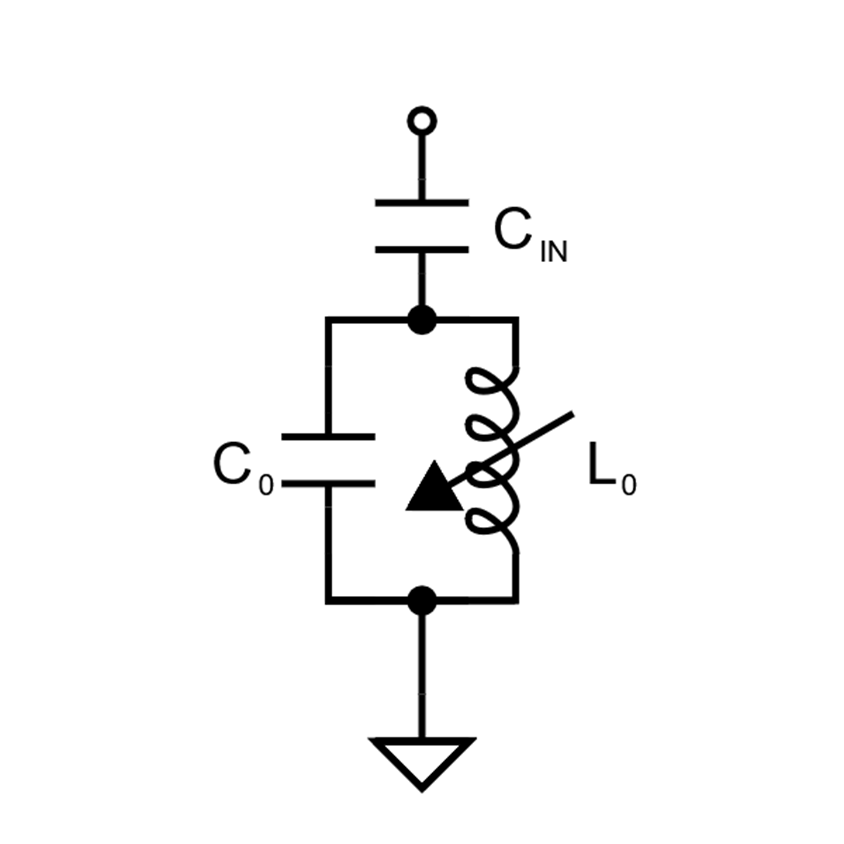

$$
Z_{LC} = \frac{\frac{1}{i\omega C_0} i\omega (L_0 + \frac{L_J}{\cos{2\pi\phi}})}{\frac{1}{i\omega C_0} + i\omega (L_0 + \frac{L_J}{\cos{2\pi\phi}})}
$$
$$
Z_{LC} = \frac{\frac{1}{i\omega C_0} i\omega L_0}{\frac{1}{i\omega C_0} + i\omega L_0}
$$
$$
Z_{LC} = \frac{\frac{1}{i\omega C_0} i\omega L_0}{\frac{1}{i\omega C_0} + i\omega L_0}\left(\frac{i\omega C_0}{i\omega C_0}\right)
$$


$$
Z = \frac{1}{i\omega C_{in}} + \frac{i\omega L_0}{1 - \omega^2C_0L_0}
$$

In [8]:
# load needed python libraries matplotlib, numpy, and scikit-rf
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
import json
from skrf.media import *
from skrf import Frequency
from scipy.optimize import curve_fit


In [ ]:
# Read in data corrected with E-cal 
data_corrected = rf.read_all('jpa-nopump-scan2-s1p-corrected')

In [46]:
# Read in raw data, un-corrected
data_raw = rf.read_all('jpa-nopump-scan2-s1p')

In [48]:
# Create frequency array
fghz = data_corrected['trace0'].f/1e9


In [58]:
# create flux bias array
file_object = open("biaswave.json", "r")
period = 1.85 # determined from looking at period of data sets
biaswave = json.loads(file_object.read())
file_object.close()
biaswave = np.array(biaswave)
phiwave = biaswave/period

(-180.0, 180.0)

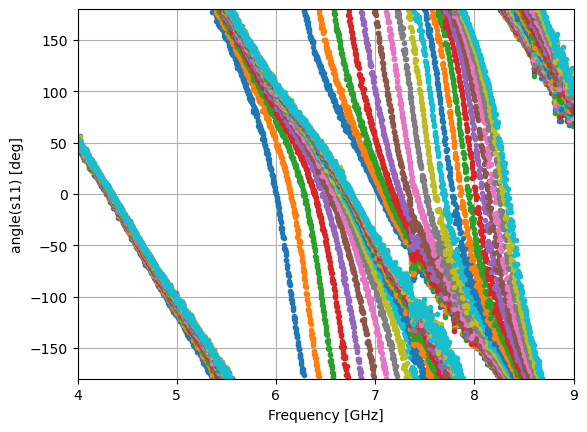

In [192]:
for index in range(20):
    plt.plot(fghz,np.angle(data_corrected['trace' + str(10*index)].s[:,0,0],deg=True),'.')

plt.grid()
plt.xlim(4,9)
plt.xlabel("Frequency [GHz]")
plt.ylabel("angle(s11) [deg]")
plt.ylim(-180,180)

$$
\times e^{2\pi  i  f t_{unwind}}
$$

(-180.0, 180.0)

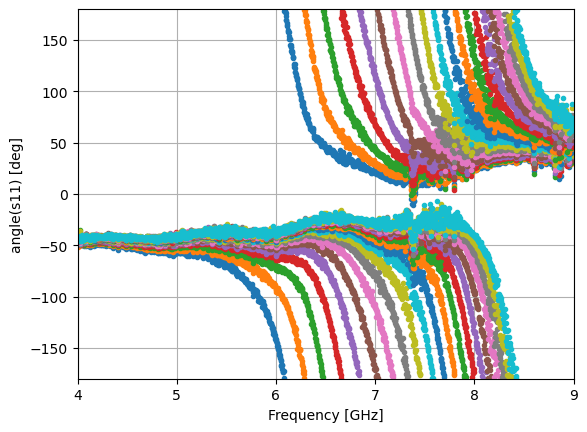

In [200]:
t_unwind = 0.434 # nanoseconds
for index in range(20):
    plt.plot(fghz,np.angle(np.exp(1j*2*np.pi*fghz*t_unwind)*data_corrected['trace' + str(10*index)].s[:,0,0],deg=True),'.')

plt.grid()
plt.xlim(4,9)
plt.xlabel("Frequency [GHz]")
plt.ylabel("angle(s11) [deg]")
plt.ylim(-180,180)

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
C:\Users\lfs\AppData\Local\Temp\1\ipykernel_19332\620287013.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.title('flux bias = ' + str(np.round(phiwave[460],4)) + ' $\phi_0$')


Text(0.5, 1.0, 'flux bias = -0.7294 $\\phi_0$')

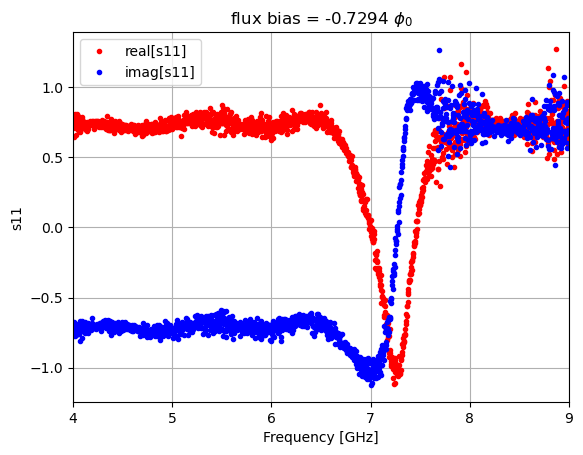

In [215]:
unwrapped_s = np.exp(1j*2*np.pi*fghz*t_unwind)*data_corrected['trace460'].s[:,0,0]

plt.plot(fghz,np.real(unwrapped_s),'.',color="red")
plt.plot(fghz,np.imag(unwrapped_s),'.',color="blue")
plt.grid()
plt.xlim(4,9)
plt.xlabel("Frequency [GHz]")
plt.ylabel("s11")
plt.legend(['real[s11]','imag[s11]'])
plt.title('flux bias = ' + str(np.round(phiwave[460],4)) + ' $\phi_0$')

In [219]:
s_unwrapped_real_imag_concat = []
for index in range(len(data_corrected)):
    unwrapped_s = np.exp(1j*2*np.pi*fghz*t_unwind)*data_corrected['trace' + str(index)].s[:,0,0]
    s_unwrapped_real_imag_concat.append(np.concatenate((np.real(unwrapped_s),np.imag(unwrapped_s))))

s_unwrapped_real_imag_concat  = np.array(s_unwrapped_real_imag_concat)

In [691]:
s_unwrapped_xy = []
for index in range(len(data_corrected)):
    s_unwrapped_xy.append(np.exp(1j*2*np.pi*fghz*t_unwind)*data_corrected['trace' + str(index)].s[:,0,0])
s_unwrapped_xy  = np.array(s_unwrapped_xy)

Text(0, 0.5, 'concatenated frequency point number')

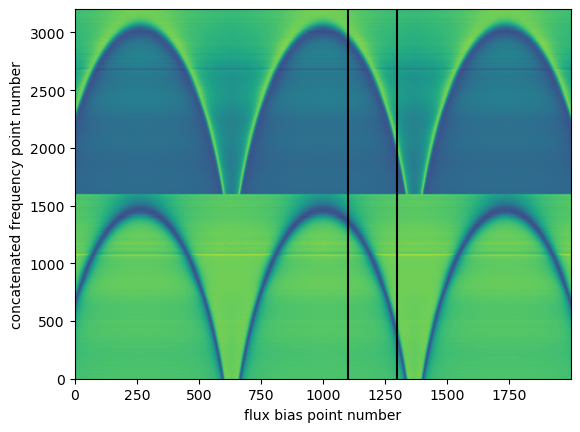

In [788]:
plt.imshow(s_unwrapped_real_imag_concat.transpose(),origin='lower',aspect='auto')
plt.vlines([1100,1300],0,len(fghzfghz),color='black')
plt.ylim(0,len(fghzfghz))
plt.xlabel('flux bias point number')
plt.ylabel('concatenated frequency point number')

In [573]:
phiwave[1100],phiwave[1300]

(0.13587875018590362, 0.4062842231926773)

In [381]:
#Create fit function with frequency concatenated on itself and returning imag contatenated on top of real
def jpa_complex_concat(frequencyghzconcat, CinpF, C0pF, L0pH, tau):
    halfnumber = int(len(frequencyghzconcat)/2)
    frequencyghz = frequencyghzconcat[0:halfnumber]
    Cin = CinpF*1e-12
    C0 = C0pF*1e-12
    L0 = L0pH*1e-12
    omega = 2*np.pi*frequencyghz*1e9
    Z_jpa = (1/(1j*omega*Cin)) + (1j*omega*L0)/(1 - omega*omega*C0*L0)
    s_jpa = (Z_jpa  - 50)/(Z_jpa + 50)
    s_jpa = s_jpa*np.exp(1j*2*np.pi*frequencyghz*tau)
    s_jpa_concat = np.concatenate((np.real(s_jpa),np.imag(s_jpa)))
    return s_jpa_concat # this minus sign is suspect, i have no idea why it's here
    
def jpa_complex(frequencyghz, CinpF, C0pF, L0pH, tau):
    Cin = CinpF*1e-12
    C0 = C0pF*1e-12
    L0 = L0pH*1e-12
    omega = 2*np.pi*frequencyghz*1e9
    Z_jpa = (1/(1j*omega*Cin)) + (1j*omega*L0)/(1 - omega*omega*C0*L0)
    s_jpa = (Z_jpa - 50)/(Z_jpa + 50)
    s_jpa = s_jpa*np.exp(-1j*2*np.pi*frequencyghz*tau)    
    return s_jpa 

In [231]:
fghzfghz = np.concatenate((fghz,fghz))

Text(0.5, 1.0, 'flux bias = 0.1359')

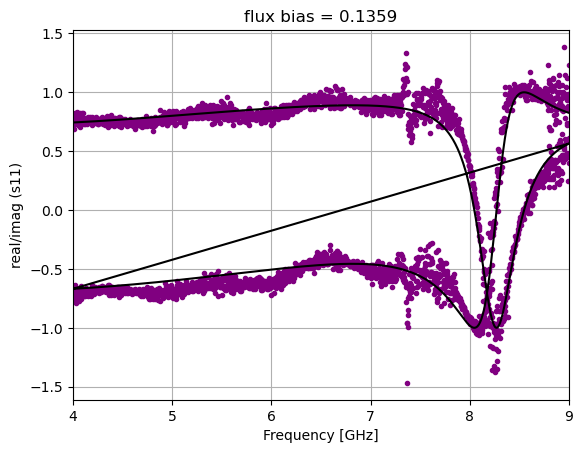

In [563]:
Cinguess = 1 #  pF
C0guess = 5.2 # pF
L0guess = 80 #  pH
tauguess = 0.047

phiindex = 1100
popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, s_unwrapped_real_imag_concat[phiindex],p0=[Cinguess,C0guess,L0guess,tauguess],bounds=((0.4*Cinguess,0.4*C0guess,0.2*L0guess,0.8*tauguess),(1.2*Cinguess,1.2*C0guess,3*L0guess,1.2*tauguess)))

plt.plot(fghzfghz,s_unwrapped_real_imag_concat[phiindex],'.',color='purple')
#plt.plot(jpa_complex_concat(fghzfghz,1,5.2,88,-0.047),color='black')
plt.plot(fghzfghz,jpa_complex_concat(fghzfghz,popt[0],popt[1],popt[2],popt[3]),color='black')
plt.xlim(fghzfghz[0],fghzfghz[len(fghzfghz)-1])
plt.grid()
plt.ylabel('real/imag (s11)')
plt.xlabel('Frequency [GHz]')
plt.title('flux bias = ' + str(np.round(phiwave[phiindex],4)))

Text(0.5, 1.0, 'flux bias = 0.4063')

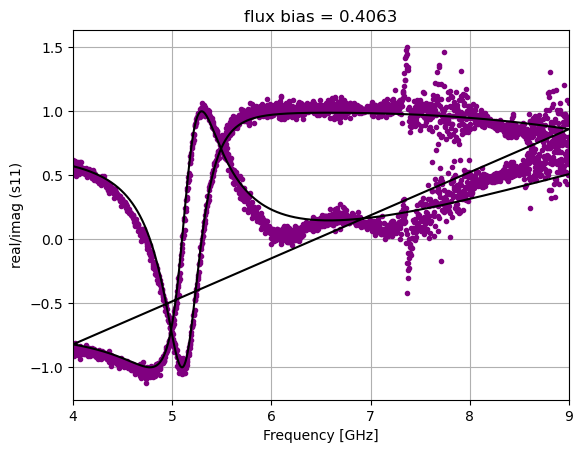

In [561]:
Cinguess = 1 #  pF
C0guess = 5.2 # pF
L0guess = 150 #  pH
tauguess = 0.047

phiindex = 1300
popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, s_unwrapped_real_imag_concat[phiindex],p0=[Cinguess,C0guess,L0guess,tauguess],bounds=((0.4*Cinguess,0.4*C0guess,0.2*L0guess,0.8*tauguess),(1.2*Cinguess,1.2*C0guess,3*L0guess,1.2*tauguess)))

plt.plot(fghzfghz,s_unwrapped_real_imag_concat[phiindex],'.',color='purple')
#plt.plot(jpa_complex_concat(fghzfghz,1,5.2,88,-0.047),color='black')
plt.plot(fghzfghz,jpa_complex_concat(fghzfghz,popt[0],popt[1],popt[2],popt[3]),color='black')
plt.xlim(fghzfghz[0],fghzfghz[len(fghzfghz)-1])
plt.grid()
plt.ylabel('real/imag (s11)')
plt.xlabel('Frequency [GHz]')
plt.title('flux bias = ' + str(np.round(phiwave[phiindex],4)))

In [517]:
phiwave[1100],phiwave[1300]

(0.13587875018590362, 0.4062842231926773)

In [920]:
Cinwave = []
C0wave = []
L0wave = []
tauwave = []
Cinsigmawave = []
C0sigmawave = []
L0sigmawave = []
tausigmawave = []
fitphiwave = []
Cinguess = 1 #  pF
C0guess = 5.2 # pF
L0guess = 80 #  pH
tauguess = 0.047
for phiindex in range(1160,1300):
    fitphiwave.append(phiwave[phiindex])
    if phiindex > 1200:
        L0guess = 150
    popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, s_unwrapped_real_imag_concat[phiindex],p0=[Cinguess,C0guess,L0guess,tauguess],bounds=((0.4*Cinguess,0.4*C0guess,0.2*L0guess,0.8*tauguess),(1.5*Cinguess,1.2*C0guess,3*L0guess,2*tauguess)))
    Cinwave.append(popt[0])
    C0wave.append(popt[1])
    L0wave.append(popt[2])
    tauwave.append(popt[3])    
    Cinsigmawave.append(np.sqrt(pcov[0,0]))
    C0sigmawave.append(np.sqrt(pcov[1,1]))
    L0sigmawave.append(np.sqrt(pcov[2,2]))
    tausigmawave.append(np.sqrt(pcov[3,3]))
Cinwave = np.array(Cinwave)
C0wave = np.array(C0wave)
L0wave = np.array(L0wave)
tauwave = np.array(tauwave)
Cinsigmawave = np.array(Cinsigmawave)
C0sigmawave = np.array(C0sigmawave)
L0sigmawave = np.array(L0sigmawave)
tausigmawave = np.array(tausigmawave)
fitphiwave = np.array(fitphiwave)

Text(0.5, 0, 'flux bias [per flux quantum]')

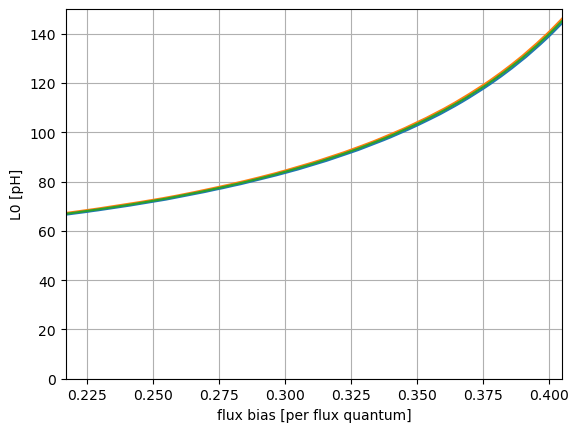

In [921]:
plt.plot(fitphiwave,L0wave - L0sigmawave)
plt.plot(fitphiwave,L0wave + L0sigmawave)
plt.plot(fitphiwave,L0wave)
plt.grid()
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave) -1])
plt.ylabel('L0 [pH]')
plt.ylim(0,150)
plt.xlabel('flux bias [per flux quantum]')

Text(0.5, 1.0, '5th order polynomial fit')

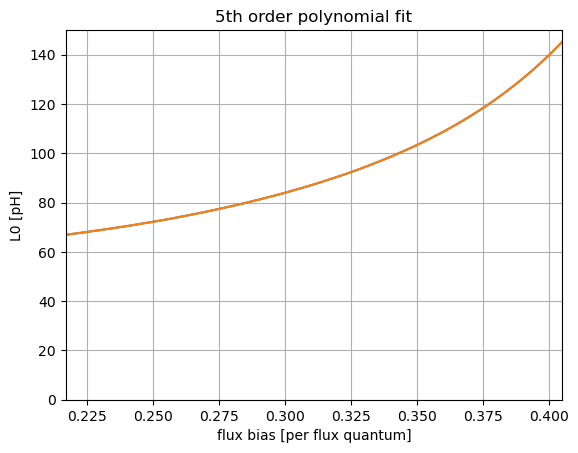

In [924]:
plt.plot(fitphiwave,L0wave)
polyterms = np.polyfit(fitphiwave,L0wave,5)
Lpoly = polyterms[0]*fitphiwave**5 + polyterms[1]*fitphiwave**4 +polyterms[2]*fitphiwave**3 +polyterms[3]*fitphiwave**2 + polyterms[4]*fitphiwave + polyterms[5]
plt.plot(fitphiwave,Lpoly)
plt.grid()
plt.ylim(0,150)

plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave)-1])
plt.ylabel('L0 [pH]')
plt.xlabel('flux bias [per flux quantum]')
plt.title('5th order polynomial fit')

(-2.0, 2.0)

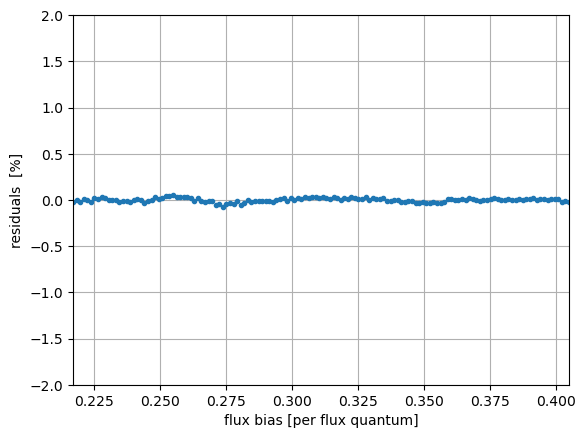

In [926]:
plt.plot(fitphiwave,100*(Lpoly - L0wave)/L0wave,'.')
plt.xlabel('flux bias [per flux quantum]')
plt.grid()
plt.ylabel('residuals  [%]')
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave)-1])
plt.ylim(-2,2)

In [928]:
Cinwave

array([1.42597331, 1.43319862, 1.43161485, 1.42704263, 1.42994484,
       1.43617893, 1.42932789, 1.44000956, 1.43128399, 1.42749917,
       1.43139678, 1.43271565, 1.43739186, 1.43781853, 1.43822412,
       1.43689742, 1.43733227, 1.43926069, 1.43224567, 1.43577734,
       1.44648668, 1.44071851, 1.44100721, 1.43511427, 1.4405369 ,
       1.43968997, 1.43586506, 1.43140805, 1.43582589, 1.43970361,
       1.44003314, 1.44536282, 1.44316723, 1.44266852, 1.45111991,
       1.4395302 , 1.45341201, 1.45341435, 1.45237748, 1.44384278,
       1.44723469, 1.45052429, 1.45383098, 1.45351858, 1.45205528,
       1.4466155 , 1.44890549, 1.45909289, 1.45330694, 1.44843807,
       1.45279389, 1.45076458, 1.45687827, 1.45322778, 1.45432375,
       1.45528628, 1.45968792, 1.45914982, 1.45756294, 1.45536771,
       1.45630313, 1.45853716, 1.45746438, 1.45829848, 1.45875096,
       1.45753632, 1.45983537, 1.45630942, 1.45210103, 1.46176066,
       1.46037987, 1.46560221, 1.46572583, 1.46482513, 1.46023

Text(0.5, 0, 'flux bias [per flux quantum]')

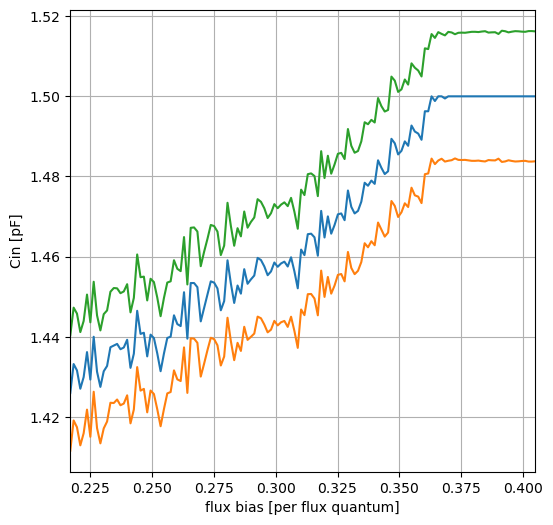

In [930]:
fig = plt.figure(figsize=(6, 6))
plt.plot(fitphiwave,Cinwave)
plt.plot(fitphiwave,Cinwave  -Cinsigmawave)
plt.plot(fitphiwave,Cinwave +Cinsigmawave)
plt.grid()
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave)-1])
#plt.ylim(1.15,1.45)
plt.ylabel('Cin [pF]')
plt.xlabel('flux bias [per flux quantum]')
#plt.hlines([1.5],fitphiwave[0],fitphiwave[len(fitphiwave)-1],color="black")
#plt.title('line is at 1.2 pF')

Text(0.5, 0, 'flux bias [per flux quantum]')

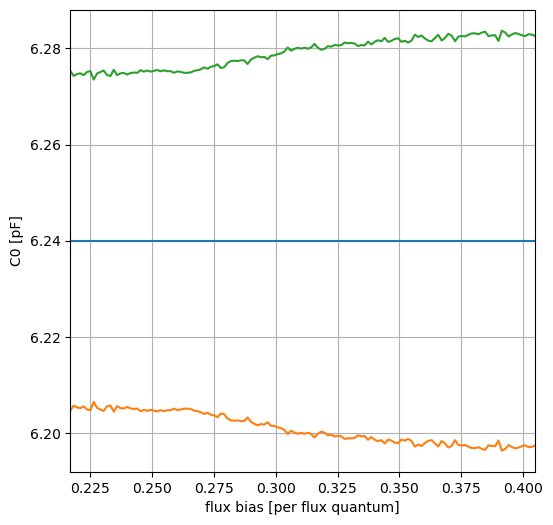

In [932]:
fig = plt.figure(figsize=(6, 6))
plt.plot(fitphiwave,C0wave)
plt.plot(fitphiwave,C0wave  - C0sigmawave)
plt.plot(fitphiwave,C0wave +  C0sigmawave)
plt.grid()
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave)-1])
plt.ylabel('C0 [pF]')
plt.xlabel('flux bias [per flux quantum]')

Text(0.5, 0, 'flux bias [per flux quantum]')

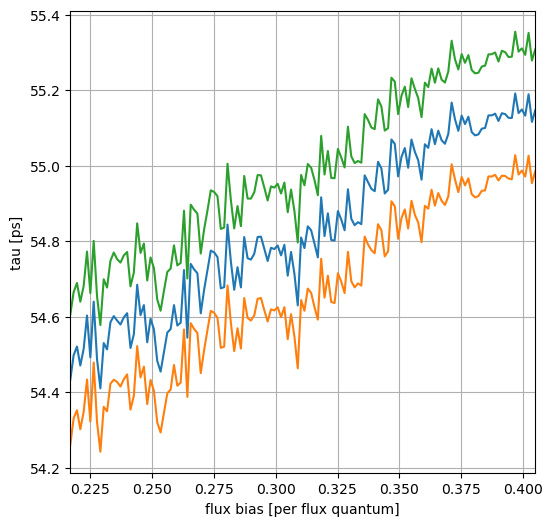

In [934]:
fig = plt.figure(figsize=(6, 6))
plt.plot(fitphiwave,1e3*tauwave)
plt.plot(fitphiwave,1e3*tauwave  - 1e3*tausigmawave)
plt.plot(fitphiwave,1e3*tauwave + 1e3*tausigmawave)
plt.grid()
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave)-1])
plt.ylabel('tau [ps]')
plt.xlabel('flux bias [per flux quantum]')

Text(0.5, 1.0, 'flux bias = 0.3252')

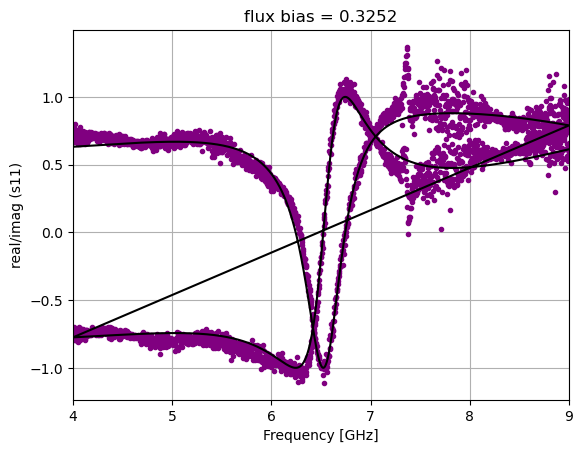

In [936]:
Cinguess = 1 #  pF
C0guess = 5.2 # pF
L0guess = 80 #  pH
tauguess = 0.047

phiindex = 1240
popt, pcov = curve_fit(jpa_complex_concat, fghzfghz, s_unwrapped_real_imag_concat[phiindex],p0=[Cinguess,C0guess,L0guess,tauguess],bounds=((0.4*Cinguess,0.4*C0guess,0.2*L0guess,0.8*tauguess),(1.5*Cinguess,1.2*C0guess,3*L0guess,1.2*tauguess)))

plt.plot(fghzfghz,s_unwrapped_real_imag_concat[phiindex],'.',color='purple')
#plt.plot(jpa_complex_concat(fghzfghz,1,5.2,88,-0.047),color='black')
plt.plot(fghzfghz,jpa_complex_concat(fghzfghz,popt[0],popt[1],popt[2],popt[3]),color='black')
plt.xlim(fghzfghz[0],fghzfghz[len(fghzfghz)-1])
plt.grid()
plt.ylabel('real/imag (s11)')
plt.xlabel('Frequency [GHz]')
plt.title('flux bias = ' + str(np.round(phiwave[phiindex],4)))

In [685]:
popt

array([1.47055599e+00, 6.24000000e+00, 9.24241256e+01, 5.48799462e-02])

In [938]:
def jpa_fixed(frequencyghz, phi):
    Cinlocal = 1.47e-12
    C0local = 6.24e-12
    L0local = 1e-12*(polyterms[0]*phi**5 + polyterms[1]*phi**4 +polyterms[2]*phi**3 +polyterms[3]*phi**2 + polyterms[4]*phi + polyterms[5])
    taulocal = 54.88e-12
    omega = 2*np.pi*frequencyghz*1e9
    Z_jpa = (1/(1j*omega*Cinlocal)) + (1j*omega*L0local)/(1 - omega*omega*C0local*L0local)
    s_jpa = (Z_jpa  - 50)/(Z_jpa + 50)    
    s_jpa = s_jpa*np.exp(1j*omega*taulocal)    
    return s_jpa

In [946]:
caltraces = []
for phiindex in range(1160,1300):
    caltraces.append(s_unwrapped_xy[phiindex])
caltraces = np.array(caltraces)

Text(0.5, 1.0, 'frequency = 6.5 GHz, findex = 800')

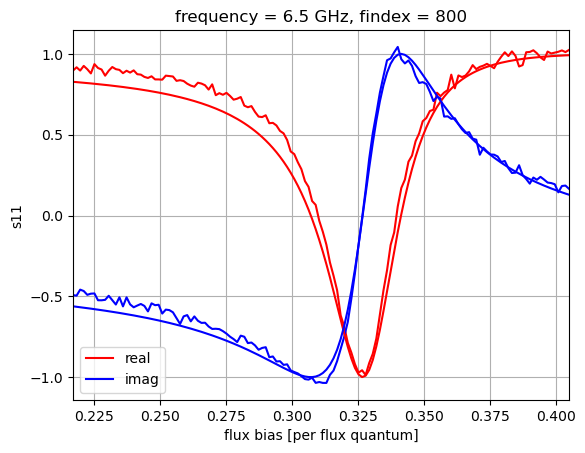

In [1012]:
findex = 800
plt.plot(fitphiwave,np.real(caltraces.transpose()[findex][:]),color="red")
plt.plot(fitphiwave,np.imag(caltraces.transpose()[findex][:]),color="blue")

plt.plot(fitphiwave,np.real(jpa_fixed(fghz[findex],fitphiwave)),color="red")
plt.plot(fitphiwave,np.imag(jpa_fixed(fghz[findex],fitphiwave)),color="blue")

plt.plot()
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave) - 1])
plt.grid()
plt.legend(["real","imag"])
plt.xlabel('flux bias [per flux quantum]')
plt.ylabel('s11')
plt.title("frequency = " + str(fghz[findex]) + " GHz, findex = "  + str(findex))


Text(0.5, 1.0, 'frequency = 6.031 GHz, findex = 650')

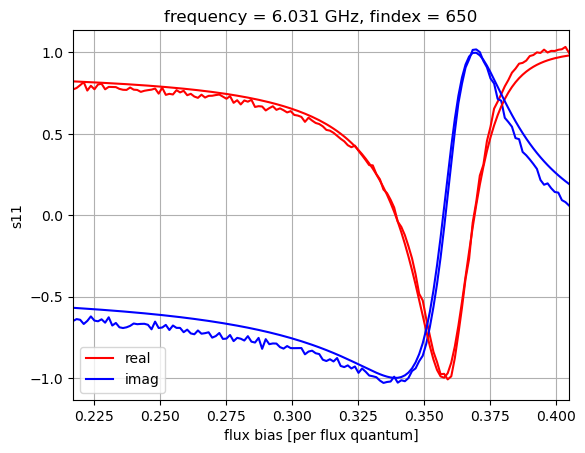

In [1014]:
findex = 650
plt.plot(fitphiwave,np.real(caltraces.transpose()[findex][0:200]),color="red")
plt.plot(fitphiwave,np.imag(caltraces.transpose()[findex][0:200]),color="blue")
plt.plot(fitphiwave,np.real(jpa_fixed(fghz[findex],fitphiwave)),color="red")
plt.plot(fitphiwave,np.imag(jpa_fixed(fghz[findex],fitphiwave)),color="blue")

plt.plot()
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave) - 1])
plt.grid()
plt.legend(["real","imag"])
plt.xlabel('flux bias [per flux quantum]')
plt.ylabel('s11')
plt.title("frequency = " + str(fghz[findex]) + " GHz, findex = "  + str(findex))


Text(0.5, 1.0, 'frequency = 6.969 GHz, findex = 950')

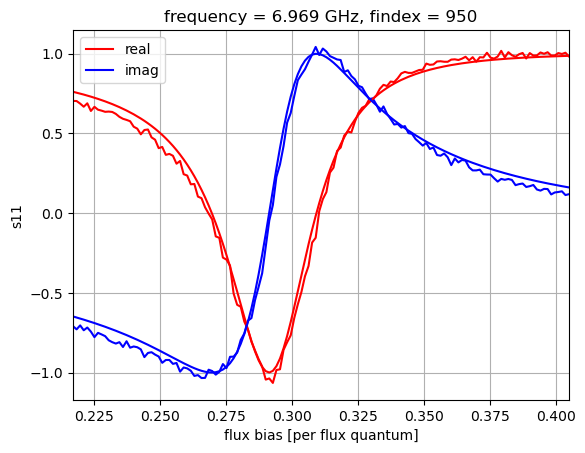

In [1016]:
findex = 950
plt.plot(fitphiwave,np.real(caltraces.transpose()[findex][0:200]),color="red")
plt.plot(fitphiwave,np.imag(caltraces.transpose()[findex][0:200]),color="blue")
plt.plot(fitphiwave,np.real(jpa_fixed(fghz[findex],fitphiwave)),color="red")
plt.plot(fitphiwave,np.imag(jpa_fixed(fghz[findex],fitphiwave)),color="blue")

plt.plot()
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave) - 1])
plt.grid()
plt.legend(["real","imag"])
plt.xlabel('flux bias [per flux quantum]')
plt.ylabel('s11')
plt.title("frequency = " + str(fghz[findex]) + " GHz, findex = "  + str(findex))


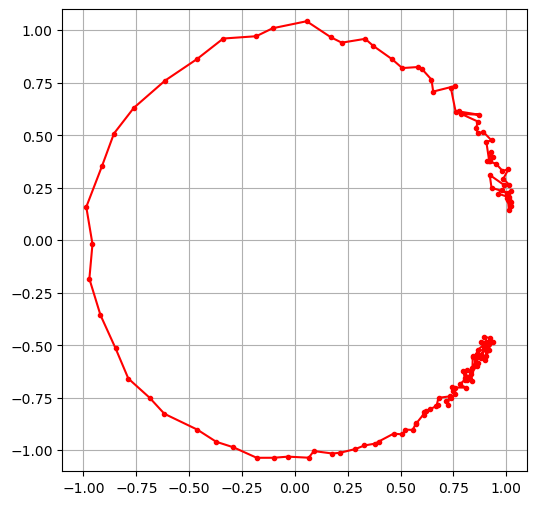

In [948]:
fig = plt.figure(figsize=(6, 6))
findex = 800
plt.plot(np.real(caltraces.transpose()[findex][0:200]),np.imag(caltraces.transpose()[findex][0:200]),color="red",marker='.')
plt.xlim([-1.1,1.1])
plt.ylim([-1.1,1.1])
plt.grid()


In [950]:
len(caltraces),len(fghz)

(140, 1601)

In [804]:
fghz

array([4.   , 4.003, 4.006, ..., 8.994, 8.997, 9.   ])

In [952]:
fghz6 = []
caltraces6 = []
for findex in range(len(fghz)-1):
    if fghz[findex] > 6.0 and fghz[findex] < 7.0:
        fghz6.append(fghz[findex])
        caltraces6.append(caltraces.transpose()[findex])
caltraces6 = np.array(caltraces6)
caltraces6 = caltraces6.transpose()

In [1264]:
fghz6 = np.array(fghz6)

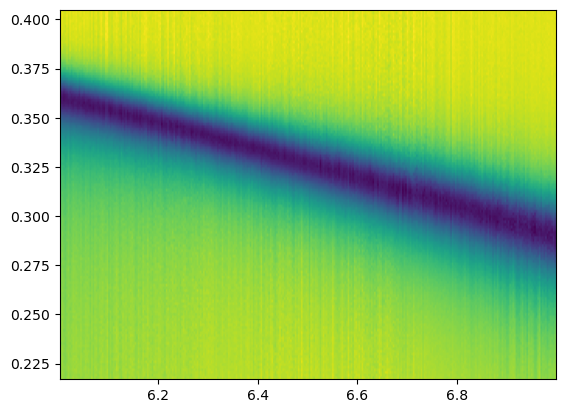

In [964]:
plt.imshow(np.real(caltraces6),extent=(fghz6[0],fghz6[len(fghz6)-1],fitphiwave[0],fitphiwave[len(fitphiwave) -1]),aspect='auto',origin='lower')

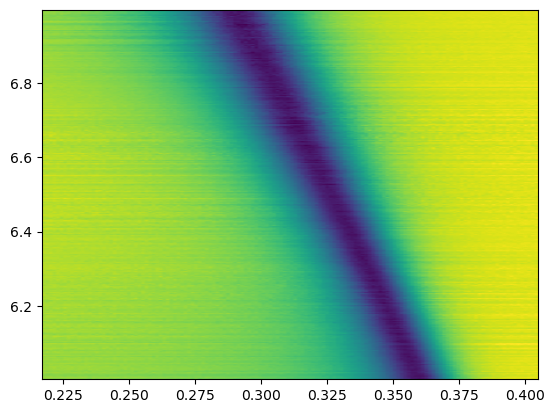

In [864]:
plt.imshow((np.real(caltraces6[60:200].transpose())),extent=(fitphiwave[60],fitphiwave[199],c[0],fghz6[len(fghz6)-1]),aspect='auto',origin='lower')

Text(0.5, 1.0, 's11 angle')

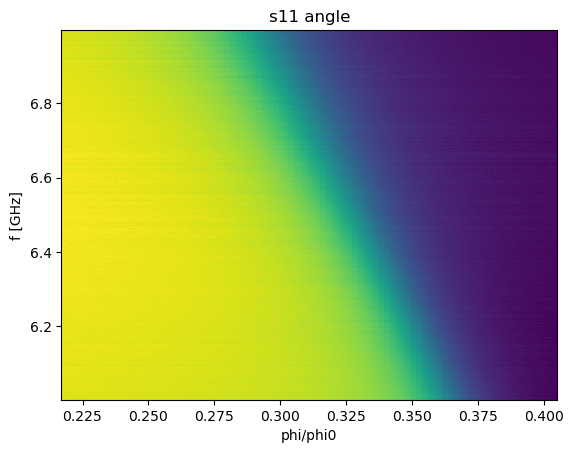

In [1130]:
plt.imshow(np.unwrap(np.angle(caltraces6.transpose())),extent=(fitphiwave[0],fitphiwave[len(fitphiwave) -1],fghz6[0],fghz6[len(fghz6)-1]),aspect='auto',origin='lower',cmap='viridis', interpolation='none')
plt.xlabel('phi/phi0')
plt.ylabel('f [GHz]')
plt.title('s11 angle')


Text(0.5, 1.0, 's11 angle')

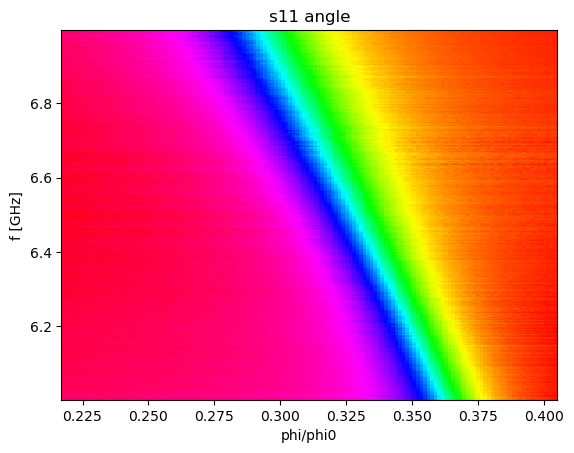

In [972]:
plt.imshow(np.unwrap(np.angle(caltraces6.transpose())),extent=(fitphiwave[0],fitphiwave[len(fitphiwave) -1],fghz6[0],fghz6[len(fghz6)-1]),aspect='auto',origin='lower',cmap='hsv', interpolation='none')
plt.xlabel('phi/phi0')
plt.ylabel('f [GHz]')
plt.title('s11 angle')

Text(0.5, 1.0, 's11 angle')

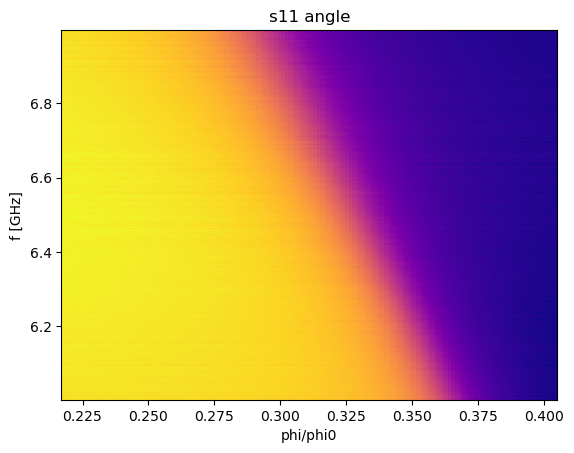

In [1210]:
plt.imshow(np.unwrap(np.angle(caltraces6.transpose())),extent=(fitphiwave[0],fitphiwave[len(fitphiwave) -1],fghz6[0],fghz6[len(fghz6)-1]),aspect='auto',origin='lower',cmap='plasma', interpolation='none')
plt.xlabel('phi/phi0')
plt.ylabel('f [GHz]')
plt.title('s11 angle')

Text(0.5, 1.0, 'Fixed Frequencies from 6.003 GHz to 6.997 GHz')

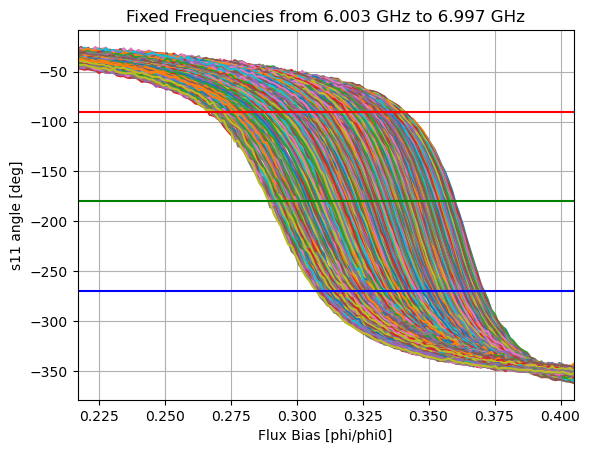

In [1038]:
plt.plot(fitphiwave,180*np.unwrap(np.angle(caltraces6.transpose())).transpose()/np.pi)
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave) - 1])
plt.ylabel('s11 angle [deg]')
plt.xlabel('Flux Bias [phi/phi0]')
plt.hlines([-90],fitphiwave[0],fitphiwave[len(fitphiwave) - 1],color='red')
plt.hlines([-180],fitphiwave[0],fitphiwave[len(fitphiwave) - 1],color='green')
plt.hlines([-270],fitphiwave[0],fitphiwave[len(fitphiwave) - 1],color='blue')

plt.grid()
plt.title('Fixed Frequencies from ' + str(np.round(fghz6[0],4)) + ' GHz to '  + str(np.round(fghz6[len(fghz6)-1],4)) + ' GHz')

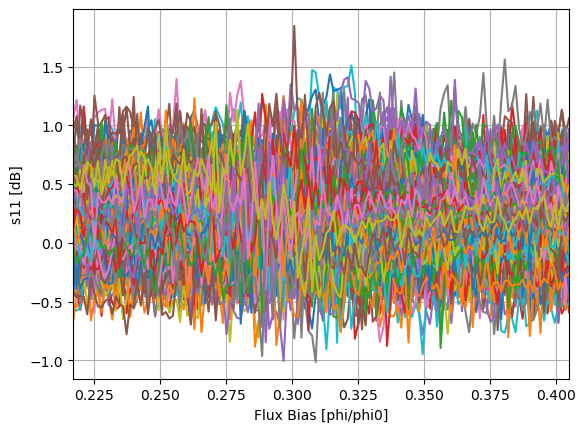

In [1042]:
plt.plot(fitphiwave,10*np.log10(np.abs(caltraces6.transpose())*np.abs(caltraces6.transpose())).transpose())
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave) - 1])
plt.xlabel('Flux Bias [phi/phi0]')
#plt.ylim(0,1.5)
plt.ylabel('s11 [dB]')
plt.grid()

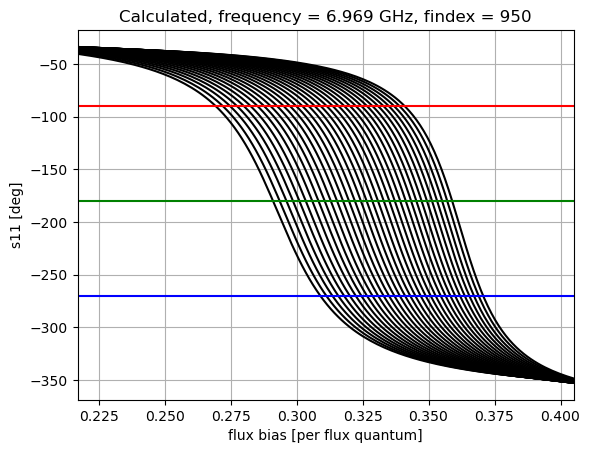

In [1048]:
for index in range(len(fghz6)):
    if index%10 == 0:
        plt.plot(fitphiwave,180*np.unwrap(np.angle(jpa_fixed(fghz6[index],fitphiwave)))/np.pi,color="black")

plt.plot()
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave) - 1])
plt.grid()
#plt.legend(["real","imag"])
plt.xlabel('flux bias [per flux quantum]')
plt.ylabel('s11 [deg]')
plt.title("Calculated, frequency = " + str(fghz[findex]) + " GHz, findex = "  + str(findex))
plt.hlines([-90],fitphiwave[0],fitphiwave[len(fitphiwave) - 1],color='red')
plt.hlines([-180],fitphiwave[0],fitphiwave[len(fitphiwave) - 1],color='green')
plt.hlines([-270],fitphiwave[0],fitphiwave[len(fitphiwave) - 1],color='blue')



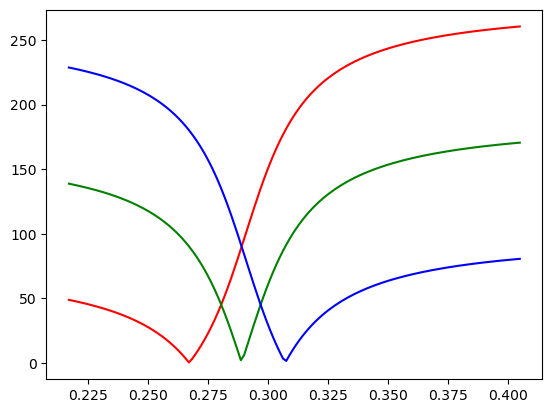

In [1082]:
plt.plot(fitphiwave,np.abs(90 + 180*np.unwrap(np.angle(jpa_fixed(fghz6[index],fitphiwave)))/np.pi),color="red")
plt.plot(fitphiwave,np.abs(180 + 180*np.unwrap(np.angle(jpa_fixed(fghz6[index],fitphiwave)))/np.pi),color="green")
plt.plot(fitphiwave,np.abs(270 + 180*np.unwrap(np.angle(jpa_fixed(fghz6[index],fitphiwave)))/np.pi),color="blue")

In [1379]:
south_measured_s = []
west_measured_s =  []
north_measured_s = []
south_ideal_swave = []
west_ideal_swave =  []
north_ideal_swave = []
southindex_wave = []
westindex_wave = []
northindex_wave = []

for findex in range(len(fghz6)):
    southindex = np.argmin(np.abs(90 + 180*np.unwrap(np.angle(jpa_fixed(fghz6[findex],fitphiwave)))/np.pi))
    westindex =  np.argmin(np.abs(180 + 180*np.unwrap(np.angle(jpa_fixed(fghz6[findex],fitphiwave)))/np.pi))
    northindex =  np.argmin(np.abs(270 + 180*np.unwrap(np.angle(jpa_fixed(fghz6[findex],fitphiwave)))/np.pi))  
    southindex_wave.append(southindex)
    westindex_wave.append(westindex)
    northindex_wave.append(northindex)
    south_ideal_swave.append(jpa_fixed(fghz6[findex],fitphiwave[southindex]))
    west_ideal_swave.append(jpa_fixed(fghz6[findex],fitphiwave[westindex]))
    north_ideal_swave.append(jpa_fixed(fghz6[findex],fitphiwave[northindex]))
    south_measured_s.append(caltraces6[southindex][findex])
    west_measured_s.append(caltraces6[westindex][findex])
    north_measured_s.append(caltraces6[northindex][findex])
    
south_ideal_swave = np.array(south_ideal_swave)
west_ideal_swave = np.array(west_ideal_swave)
north_ideal_swave = np.array(north_ideal_swave)
south_measured_s = np.array(south_measured_s)
west_measured_s = np.array(west_measured_s)
north_measured_s = np.array(north_measured_s)

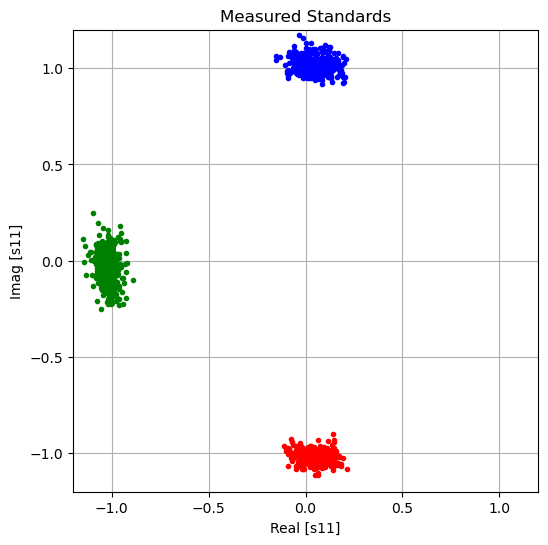

In [1124]:
fig = plt.figure(figsize=(6, 6))

plt.plot(np.real(south_ideal_swave),np.imag(south_ideal_swave),'.',color='red')
plt.plot(np.real(west_ideal_swave),np.imag(west_ideal_swave),'.',color='green')
plt.plot(np.real(north_ideal_swave),np.imag(north_ideal_swave),'.',color='blue')

plt.plot(np.real(south_measured_s),np.imag(south_measured_s),'.',color='red')
plt.plot(np.real(west_measured_s),np.imag(west_measured_s),'.',color='green')
plt.plot(np.real(north_measured_s),np.imag(north_measured_s),'.',color='blue')

plt.xlabel('Real [s11]')
plt.ylabel('Imag [s11]')
plt.title('Measured Standards')
plt.xlim([-1.2,1.2])
plt.ylim([-1.2,1.2])
plt.grid()

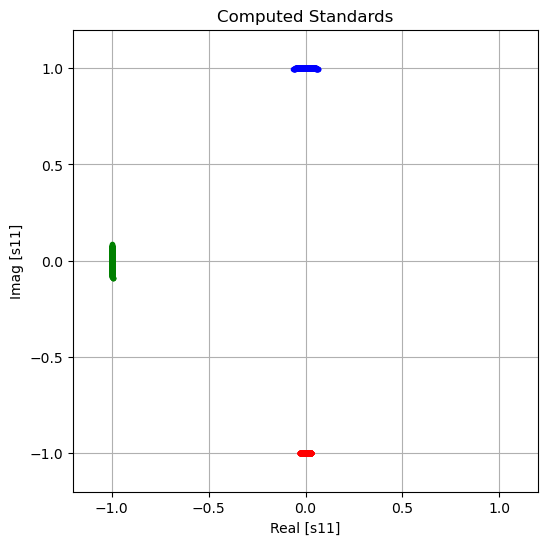

In [1122]:
fig = plt.figure(figsize=(6, 6))

plt.plot(np.real(south_ideal_swave),np.imag(south_ideal_swave),'.',color='red')
plt.plot(np.real(west_ideal_swave),np.imag(west_ideal_swave),'.',color='green')
plt.plot(np.real(north_ideal_swave),np.imag(north_ideal_swave),'.',color='blue')
plt.xlabel('Real [s11]')
plt.ylabel('Imag [s11]')
plt.title('Computed Standards')
plt.xlim([-1.2,1.2])
plt.ylim([-1.2,1.2])
plt.grid()

In [1148]:
skrf_frequency = Frequency(fghz6[0],fghz6[len(fghz6) - 1],len(fghz6),unit='GHz')

In [1158]:
south_measured    = rf.Network(frequency = skrf_frequency,s = south_measured_s)
west_measured     = rf.Network(frequency = middlefreq,s = west_measured_s)
north_measured    = rf.Network(frequency = middlefreq,s = north_measured_s)

south_ideal    = rf.Network(frequency = skrf_frequency,s = south_ideal_swave)
west_ideal   = rf.Network(frequency = skrf_frequency,s = west_ideal_swave)
north_ideal = rf.Network(frequency = skrf_frequency,s = north_ideal_swave)
my_measured = [\
        south_measured,
        west_measured,
        north_measured,
]
my_ideals = [\
        south_ideal,
        west_ideal,
        north_ideal,
]
cal_SWN = rf.OnePort(\
        ideals = my_ideals,
        measured = my_measured,
        )
cal_SWN.run()

Text(0.5, 1.0, 'Directivity')

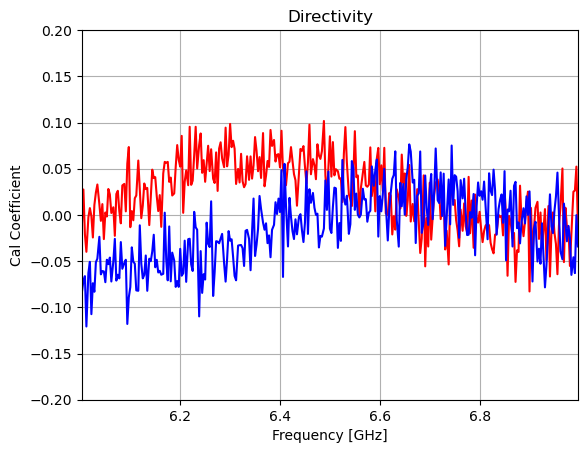

In [1200]:
plt.plot(fghz6,np.real(cal_SWN.coefs['directivity']),color='red')
plt.plot(fghz6,np.imag(cal_SWN.coefs['directivity']),color='blue')
plt.grid()
plt.xlim(fghz6[0],fghz6[len(fghz6) - 1])
plt.ylim(-0.2,0.2)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Cal Coefficient')
plt.title('Directivity')

Text(0.5, 1.0, 'Source Match')

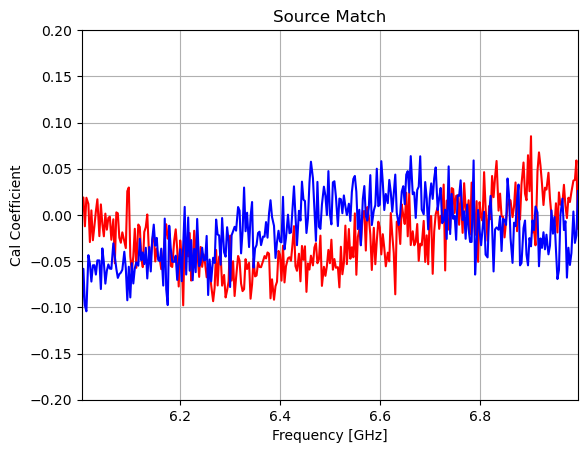

In [1202]:
plt.plot(fghz6,np.real(cal_SWN.coefs['source match']),color='red')
plt.plot(fghz6,np.imag(cal_SWN.coefs['source match']),color='blue')
plt.grid()
plt.xlim(fghz6[0],fghz6[len(fghz6) - 1])
plt.ylim(-0.2,0.2)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Cal Coefficient')
plt.title('Source Match')

Text(0.5, 1.0, 'Reflection Tracking')

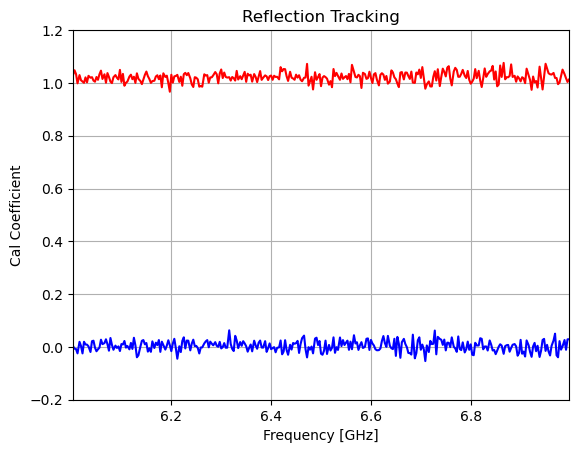

In [1208]:
plt.plot(fghz6,np.real(cal_SWN.coefs['reflection tracking']),color='red')
plt.plot(fghz6,np.imag(cal_SWN.coefs['reflection tracking']),color='blue')
plt.grid()
plt.xlim(fghz6[0],fghz6[len(fghz6) - 1])
plt.ylim(-0.2,1.2)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Cal Coefficient')
plt.title('Reflection Tracking')

In [1212]:
s_raw_xy = []
for index in range(len(data_corrected)):
    s_raw_xy.append(data_raw['trace' + str(index)].s[:,0,0])
s_raw_xy  = np.array(s_raw_xy)

In [1214]:
caltraces_raw = []
for phiindex in range(1160,1300):
    caltraces_raw.append(s_raw_xy[phiindex])
caltraces_raw = np.array(caltraces_raw)

In [1216]:
caltraces6_raw = []
for findex in range(len(fghz)-1):
    if fghz[findex] > 6.0 and fghz[findex] < 7.0:
        caltraces6_raw.append(caltraces_raw.transpose()[findex])
caltraces6_raw = np.array(caltraces6_raw)
caltraces6_raw = caltraces6_raw.transpose()

Text(0.5, 1.0, 's11 angle')

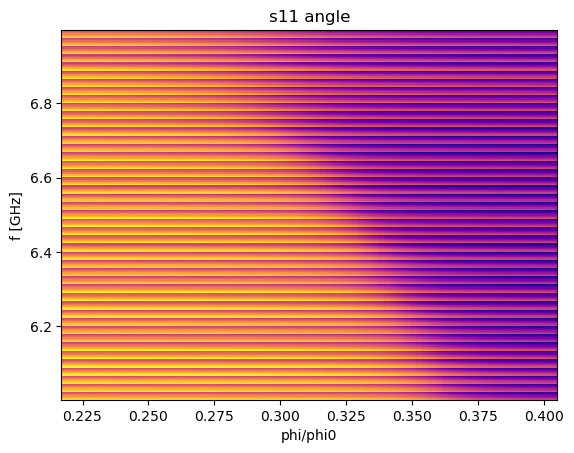

In [1218]:
plt.imshow(np.unwrap(np.angle(caltraces6_raw.transpose())),extent=(fitphiwave[0],fitphiwave[len(fitphiwave) -1],fghz6[0],fghz6[len(fghz6)-1]),aspect='auto',origin='lower',cmap='plasma', interpolation='none')
plt.xlabel('phi/phi0')
plt.ylabel('f [GHz]')
plt.title('s11 angle')

In [1220]:
south_measured_raw_s = []
west_measured_raw_s =  []
north_measured_raw_s = []

for findex in range(len(fghz6)):
    southindex = np.argmin(np.abs(90 + 180*np.unwrap(np.angle(jpa_fixed(fghz6[findex],fitphiwave)))/np.pi))
    westindex =  np.argmin(np.abs(180 + 180*np.unwrap(np.angle(jpa_fixed(fghz6[findex],fitphiwave)))/np.pi))
    northindex =  np.argmin(np.abs(270 + 180*np.unwrap(np.angle(jpa_fixed(fghz6[findex],fitphiwave)))/np.pi))  
    south_measured_raw_s.append(caltraces6_raw[southindex][findex])
    west_measured_raw_s.append(caltraces6_raw[westindex][findex])
    north_measured_raw_s.append(caltraces6_raw[northindex][findex])
    
south_measured_raw_s = np.array(south_measured_raw_s)
west_measured_raw_s = np.array(west_measured_raw_s)
north_measured_raw_s = np.array(north_measured_raw_s)

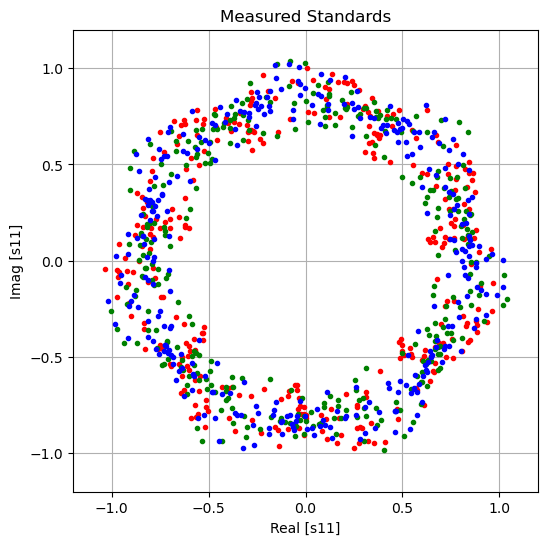

In [1222]:
fig = plt.figure(figsize=(6, 6))

plt.plot(np.real(south_measured_raw_s),np.imag(south_measured_raw_s),'.',color='red')
plt.plot(np.real(west_measured_raw_s),np.imag(west_measured_raw_s),'.',color='green')
plt.plot(np.real(north_measured_raw_s),np.imag(north_measured_raw_s),'.',color='blue')

plt.xlabel('Real [s11]')
plt.ylabel('Imag [s11]')
plt.title('Measured Standards')
plt.xlim([-1.2,1.2])
plt.ylim([-1.2,1.2])
plt.grid()

In [1224]:
south_measured_raw    = rf.Network(frequency = skrf_frequency,s = south_measured_raw_s)
west_measured_raw     = rf.Network(frequency = middlefreq,s = west_measured_raw_s)
north_measured_raw    = rf.Network(frequency = middlefreq,s = north_measured_raw_s)

my_measured_raw = [\
        south_measured_raw,
        west_measured_raw,
        north_measured_raw,
]

cal_SWN_raw = rf.OnePort(\
        ideals = my_ideals,
        measured = my_measured_raw,
        )
cal_SWN_raw.run()

Text(0.5, 1.0, 'Reflection Tracking')

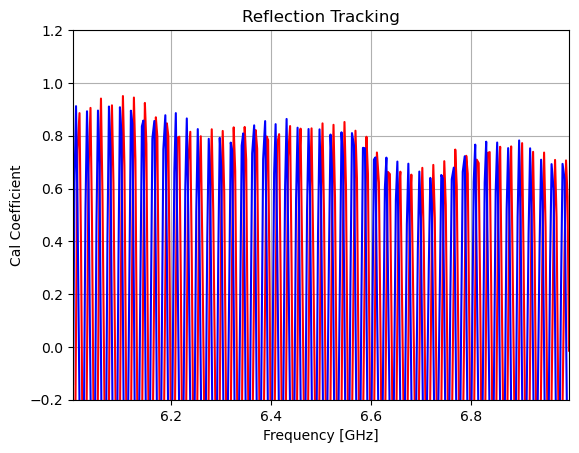

In [1226]:
plt.plot(fghz6,np.real(cal_SWN_raw.coefs['reflection tracking']),color='red')
plt.plot(fghz6,np.imag(cal_SWN_raw.coefs['reflection tracking']),color='blue')
plt.grid()
plt.xlim(fghz6[0],fghz6[len(fghz6) - 1])
plt.ylim(-0.2,1.2)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Cal Coefficient')
plt.title('Reflection Tracking')

Text(0.5, 1.0, 'Directivity')

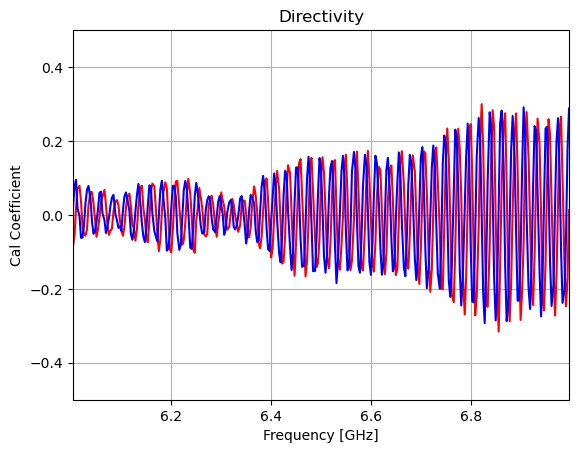

In [1230]:
plt.plot(fghz6,np.real(cal_SWN_raw.coefs['directivity']),color='red')
plt.plot(fghz6,np.imag(cal_SWN_raw.coefs['directivity']),color='blue')
plt.grid()
plt.xlim(fghz6[0],fghz6[len(fghz6) - 1])
plt.ylim(-0.5,0.5)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Cal Coefficient')
plt.title('Directivity')

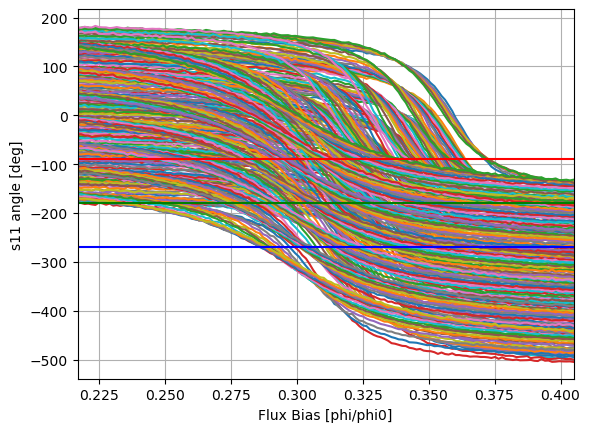

In [1232]:
plt.plot(fitphiwave,180*np.unwrap(np.angle(caltraces6_raw.transpose())).transpose()/np.pi)
plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave) - 1])
plt.ylabel('s11 angle [deg]')
plt.xlabel('Flux Bias [phi/phi0]')
plt.hlines([-90],fitphiwave[0],fitphiwave[len(fitphiwave) - 1],color='red')
plt.hlines([-180],fitphiwave[0],fitphiwave[len(fitphiwave) - 1],color='green')
plt.hlines([-270],fitphiwave[0],fitphiwave[len(fitphiwave) - 1],color='blue')

plt.grid()
#plt.title('Fixed Frequencies from ' + str(np.round(fghz6[0],4)) + ' GHz to '  + str(np.round(fghz6[len(fghz6)-1],4)) + ' GHz')

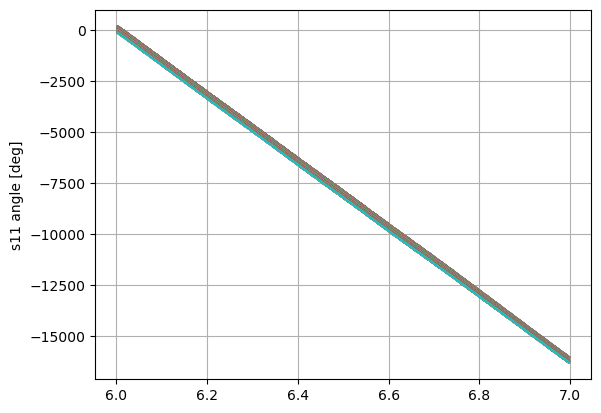

In [1242]:
plt.plot(fghz6,180*np.unwrap(np.angle(caltraces6_raw)).transpose()/np.pi)
#plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave) - 1])
plt.ylabel('s11 angle [deg]')
#plt.xlabel('Flux Bias [phi/phi0]')

plt.grid()

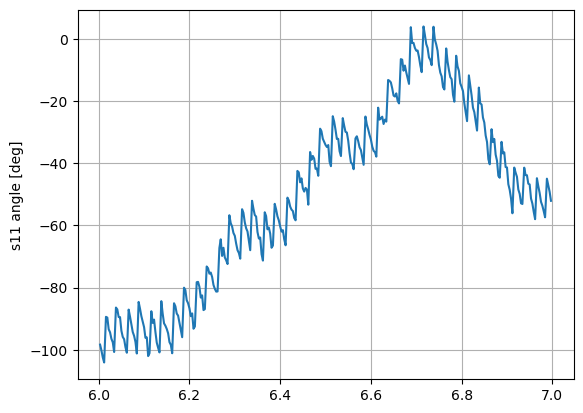

In [1296]:
plt.plot(fghz6,np.angle(np.exp(1j*fghz6*285)*caltraces6_raw[20],deg=True))
#plt.xlim(fitphiwave[0],fitphiwave[len(fitphiwave) - 1])
plt.ylabel('s11 angle [deg]')
#plt.xlabel('Flux Bias [phi/phi0]')

plt.grid()

Text(0.5, 1.0, 's11 angle')

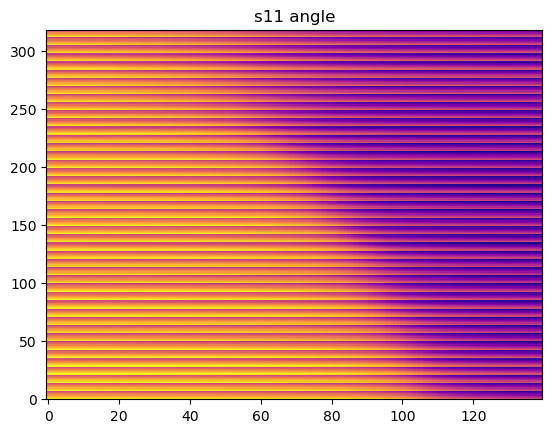

In [1313]:
plt.imshow(np.unwrap(np.angle(caltraces6_raw.transpose())),aspect='auto',origin='lower',cmap='plasma', interpolation='none')
#plt.xlabel('phi/phi0')
#plt.ylabel('f [GHz]')
plt.title('s11 angle')

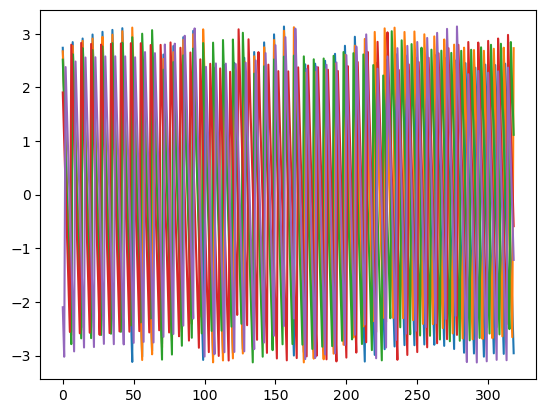

In [1331]:
plt.plot(np.angle(caltraces6_raw[phindex]))

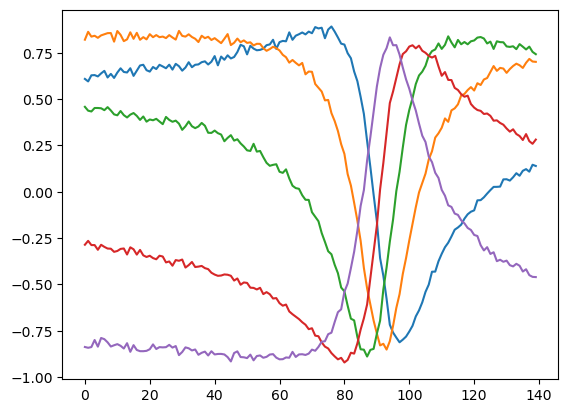

In [1367]:
for findex in range(100,105):
    #plt.plot(np.real(caltraces6_raw.transpose()[findex]))
    plt.plot(np.imag(caltraces6_raw.transpose()[findex]))

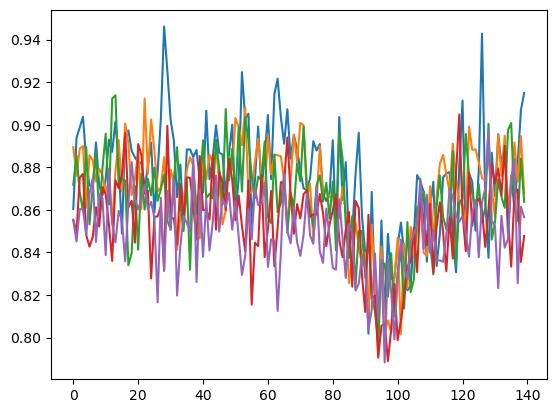

In [1365]:
for findex in range(75,80):
    #plt.plot(np.real(caltraces6_raw.transpose()[findex]))
    plt.plot(np.abs(caltraces6_raw.transpose()[findex]))

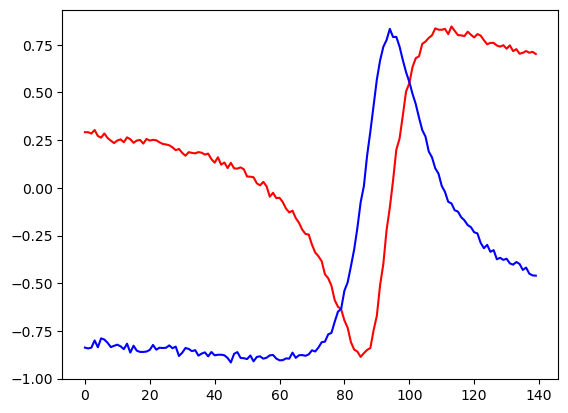

In [1369]:
plt.plot(np.real(caltraces6_raw.transpose()[findex]),color='red')
plt.plot(np.imag(caltraces6_raw.transpose()[findex]),color='blue')

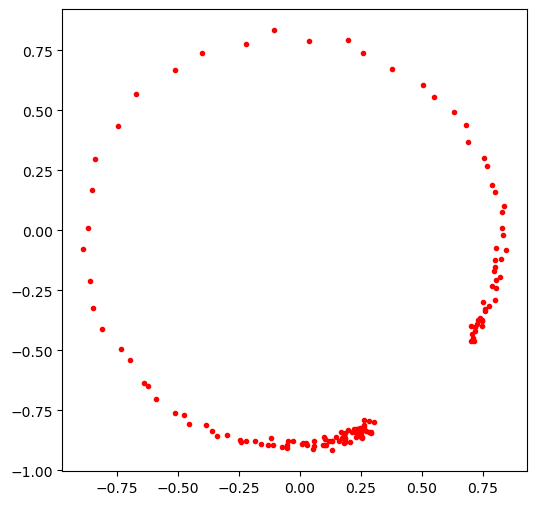

In [1375]:
fig = plt.figure(figsize=(6, 6))

plt.plot(np.real(caltraces6_raw.transpose()[findex]),np.imag(caltraces6_raw.transpose()[findex]),'.',color='red')


In [1383]:
southindex_wave[findex],westindex_wave[findex],northindex_wave[findex]


(37, 53, 67)

In [1387]:
fitphiwave[southindex_wave[findex]],fitphiwave[westindex_wave[findex]],fitphiwave[northindex_wave[findex]]

(0.26702540459418894, 0.28865784243473075, 0.30758622554520487)

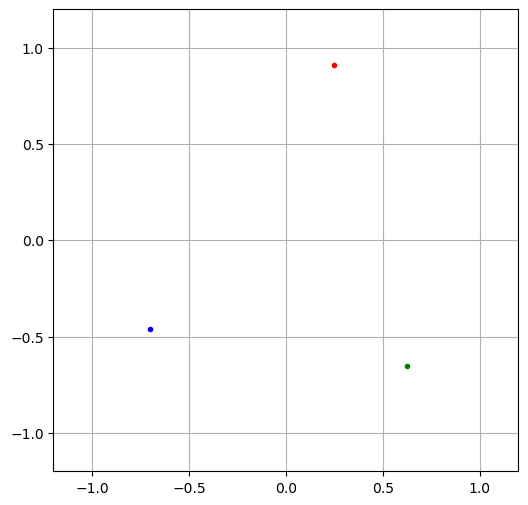

In [1403]:
findex = 150
fig = plt.figure(figsize=(6, 6))

plt.plot(np.real(caltraces6_raw.transpose()[findex][southindex_wave[findex]]),np.imag(caltraces6_raw.transpose()[findex][southindex_wave[findex]]),'.',color='red')
plt.plot(np.real(caltraces6_raw.transpose()[findex][westindex_wave[findex]]),np.imag(caltraces6_raw.transpose()[findex][westindex_wave[findex]]),'.',color='green')
plt.plot(np.real(caltraces6_raw.transpose()[findex][northindex_wave[findex]]),np.imag(caltraces6_raw.transpose()[findex][northindex_wave[findex]]),'.',color='blue')
plt.xlim([-1.2,1.2])
plt.ylim([-1.2,1.2])
plt.grid()

In [1407]:
caltraces6_raw.transpose()[findex][southindex_wave[findex]],caltraces6_raw.transpose()[findex][westindex_wave[findex]],caltraces6_raw.transpose()[findex][northindex_wave[findex]]

((0.2488+0.9116j), (0.6246-0.6524j), (-0.7033-0.4619j))